# 🚗 AI System for Car Price Prediction
    Business Scenario
    A used car marketplace company wants to build an AI-based price recommendation system.
    Currently, dealers manually estimate the price of cars based on experience. This often leads to:
    Incorrect pricing
    Loss of potential buyers
    Inconsistent valuations
    To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.

## Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset.
    The system should learn relationships between features such as:
    Car brand
    Fuel type
    Engine size
    Mileage
    Transmission
    Other attributes
    and predict the expected car price.

## CarPrice_dataset.csv
    The dataset contains multiple features describing different cars.
    Example features may include:
    brand
    fuel type
    engine size
    mileage
    transmission
    horsepower
    number of doors
    car body type
    Target variable:
    Price

## Importing the neccessary libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.datasets import load_iris
from tensorflow import argmax # For converting probabilities to class labels
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

## 🔹 Task 1 — Data Understanding
    Load the dataset and analyze it.
    Students must:
    Load dataset using pandas
    Display first 5 rows
    Check dataset information
    Check missing values
    Show statistical summary

### Loading the dataset

In [3]:
# mouting the drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# listing the files in the dataset directory
import os
dataset_dir = '/content/drive'
os.listdir(dataset_dir)

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

In [5]:
os.listdir('/content/drive/MyDrive/')

['IMG-20240804-WA0000.jpg',
 'S50242200390405.pdf',
 'CSE BTech 3rd &4th years R22 CS and SYLLABUS 2024-25  (6-02-2025).pdf.gdrive',
 'Colab Notebooks',
 'Apriori_2.py',
 'Copy of CSE BTech 3rd &4th years R22 CS and SYLLABUS 2024-25  (6-02-2025).pdf.gdrive',
 '23B81A0523_DS 1.pdf',
 'report_1758117564972.pdf',
 'Screenshot_20250917-194243 (2).png',
 'Screenshot_20250917-194243 (1).png',
 'Screenshot_20250917-194243.png',
 'IMG-20250919-WA0014.jpg',
 'Screenshot_20250919-202335 (2).png',
 'Screenshot_20250919-202335 (1).png',
 'Screenshot_20250919-202335.png',
 'report_1758295583089.pdf',
 'Screenshot_20250920-204323 (2).png',
 'Screenshot_20250920-204323 (1).png',
 'Screenshot_20250920-204323.png',
 'report_1758381299832.pdf',
 'Screenshot_20250922-202350 (2).png',
 'Screenshot_20250922-202350 (1).png',
 'Screenshot_20250922-202350.png',
 'report_1758552862123.pdf',
 'Audio from Kiran',
 'Abstract552[1].pdf',
 'Abstract552[1] (2).gdoc',
 'Abstract552[1] (1).gdoc',
 'Abstract552[1].gdoc

In [6]:
df = pd.read_csv('/content/drive/MyDrive/CarPrice_dataset.csv')

In [7]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [9]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [10]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [11]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

## 🔹 Task 2 — Data Cleaning
    Students must:
    Handle missing values
    Remove duplicates
    Fix inconsistent data types

No missing values

In [12]:
# removing the duplicates
df.drop_duplicates(inplace=True)

In [13]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [14]:
# chaning the data types of the object columns to category
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')



In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   car_ID            205 non-null    int64   
 1   symboling         205 non-null    int64   
 2   CarName           205 non-null    category
 3   fueltype          205 non-null    category
 4   aspiration        205 non-null    category
 5   doornumber        205 non-null    category
 6   carbody           205 non-null    category
 7   drivewheel        205 non-null    category
 8   enginelocation    205 non-null    category
 9   wheelbase         205 non-null    float64 
 10  carlength         205 non-null    float64 
 11  carwidth          205 non-null    float64 
 12  carheight         205 non-null    float64 
 13  curbweight        205 non-null    int64   
 14  enginetype        205 non-null    category
 15  cylindernumber    205 non-null    category
 16  enginesize        205 non-

## 🔹Task 3 — Data Preprocessing
    Students must prepare data for neural network.
    Required steps:
    Encode categorical variables
    Example:
    Fuel Type → Petrol / Diesel → One Hot Encoding
    Transmission → Manual / Automatic
    Normalize numerical features
    Example:
    MinMaxScaler
    or
    StandardScaler
    Split dataset
    Train → 80%
    Test → 20%

In [16]:
## encoding the categorical variables using label encoding
from sklearn.calibration import LabelEncoder


label = LabelEncoder()
for col in df.select_dtypes(include='category').columns:
    df[col] = label.fit_transform(df[col])


In [17]:
## Encoding the categorical variables
# creating a copy of the dataframe to encode the categorical variables
df_encoded = df.copy()
# encoding the categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df_encoded, drop_first=True)
df_encoded.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,2,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,3,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,1,1,0,1,2,2,0,94.5,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,4,1,0,0,3,1,0,99.8,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,5,1,0,0,3,0,0,99.4,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.0


In [18]:
## Standardizing the numerical features
StandardScaler = StandardScaler()
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
df_encoded[numerical_cols] = StandardScaler.fit_transform(df_encoded[numerical_cols])
df_encoded.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,-1.723622,1.743470,-1.838221,0.328798,-0.469295,1.130388,-3.050975,1.213330,-0.121867,-1.690772,...,0.074449,0.869568,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059,0.027391
1,-1.706724,1.743470,-1.813780,0.328798,-0.469295,1.130388,-3.050975,1.213330,-0.121867,-1.690772,...,0.074449,0.869568,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059,0.404461
2,-1.689826,0.133509,-1.862662,0.328798,-0.469295,1.130388,-0.717207,1.213330,-0.121867,-0.708596,...,0.604046,0.869568,-2.404880,0.685946,-0.288349,1.264536,-0.262960,-0.953012,-0.691627,0.404461
3,-1.672928,0.938490,-1.789339,0.328798,-0.469295,-0.884652,0.449677,-0.589081,-0.121867,0.173698,...,-0.431076,0.869568,-0.517266,0.462183,-0.035973,-0.053668,0.787855,-0.186865,-0.109354,0.084485
4,-1.656029,0.938490,-1.764897,0.328798,-0.469295,-0.884652,0.449677,-2.391492,-0.121867,0.107110,...,0.218885,0.869568,-0.517266,0.462183,-0.540725,0.275883,0.787855,-1.106241,-1.273900,0.523668


In [19]:
# splitting the data into features and target variable
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 🔹 Task 4 — Build Feed Forward Neural Network
    must design an FNN model.
    Architecture example:
    Input Layer → Hidden Layer → Hidden Layer → Output Layer
    Example configuration:
    Input Layer: Number of features
    Hidden Layer 1: 64 neurons (ReLU)
    Hidden Layer 2: 32 neurons (ReLU)
    Output Layer: 1 neuron (Price)

In [21]:
# building the model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

## 🔹 Task 5 — Train the Model
    You must train the neural network.
    Example configuration:
    Loss Function → Mean Squared Error
    Optimizer → Adam
    Epochs → 50
    Batch Size → 32
    You must visualize:
    Training Loss vs Epochs

In [23]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [24]:
# training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 373ms/step - loss: 1.4431 - val_loss: 1.4218
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.8064 - val_loss: 1.0005
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6495 - val_loss: 0.6859
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4462 - val_loss: 0.4790
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3125 - val_loss: 0.3616
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2729 - val_loss: 0.3055
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2082 - val_loss: 0.2853
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1444 - val_loss: 0.2750
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1399 - val_loss: 0.2715
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1367 - val_loss: 0.2708
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0963 - val_loss: 0.2709
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0874 - val_l

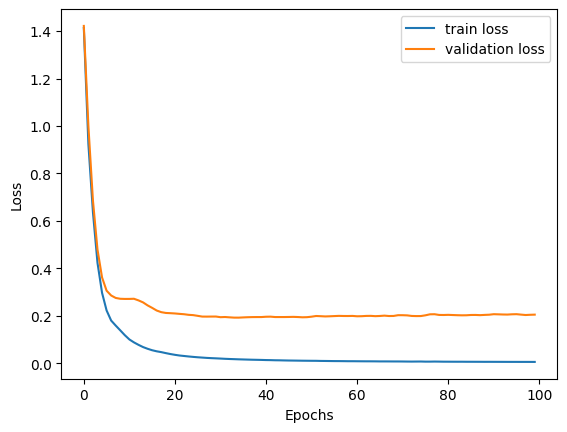

In [25]:
## visualizing the training and validation loss
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'], label='train loss')
plt.plot(model.history.history['val_loss'], label='validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## 🔹 Task 6 — Model Evaluation
    Evaluate the model using regression metrics.
    Students must compute:
    Mean Absolute Error (MAE)
    Mean Squared Error (MSE)
    Root Mean Squared Error (RMSE)
    R² Score

In [26]:
# model evaluation
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()  # Flatten the predictions to 1D array
# computing MAE, MSE, RMSE, R-squared
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R-squared: {r2}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
MAE: 0.26320531411405035
MSE: 0.12607129562440356
RMSE: 0.3550651991175755
R-squared: 0.8844350905412663


## 🔹 Task 7 — Prediction
    must test the model with new car data.
    Example:
    Brand: Toyota
    Fuel Type: Petrol
    Engine Size: 1800
    Mileage: 15 km/l
    Transmission: Manual
    Model should output:
    Predicted Price = ₹8,45,000

In [27]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [31]:
first_car_features = X.iloc[[0]]
predicted_price_scaled = model.predict(first_car_features)

temp_dummy = np.zeros((1, len(df_encoded.columns)))
price_col_index = list(df_encoded.columns).index('price')
temp_dummy[0, price_col_index] = predicted_price_scaled

unscaled_data = StandardScaler.inverse_transform(temp_dummy)
final_predicted_price = unscaled_data[0, price_col_index]

actual_price = df.iloc[0]['price']

print(f"Actual Price: {actual_price}")
print(f"Predicted Price: {final_predicted_price}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Actual Price: 13495.0
Predicted Price: 13493.68618147798


/tmp/ipykernel_1061/614290124.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp_dummy[0, price_col_index] = predicted_price_scaled


In [32]:
# for 10 records
results = []

for i in range(10):
    current_features = X.iloc[[i]]
    predicted_scaled = model.predict(current_features, verbose=0)
    
    temp_dummy = np.zeros((1, len(df_encoded.columns)))
    price_col_index = list(df_encoded.columns).index('price')
    temp_dummy[0, price_col_index] = predicted_scaled
    
    unscaled_data = StandardScaler.inverse_transform(temp_dummy)
    final_predicted = unscaled_data[0, price_col_index]
    
    actual_val = df.iloc[i]['price']
    
    results.append({
        'Car Index': i,
        'Actual Price': round(actual_val, 2),
        'Predicted Price': round(final_predicted, 2),
        'Difference': round(abs(actual_val - final_predicted), 2)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

/tmp/ipykernel_1061/3036709254.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp_dummy[0, price_col_index] = predicted_scaled
/tmp/ipykernel_1061/3036709254.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp_dummy[0, price_col_index] = predicted_scaled
/tmp/ipykernel_1061/3036709254.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp_dummy[0, price_col_index] = predicted_scaled
/tmp/ipykernel_1061/3036709254.py:10: DeprecationWarning: Conversio

   Car Index  Actual Price  Predicted Price  Difference
0          0      13495.00         13493.69        1.31
1          1      16500.00         13481.81     3018.19
2          2      16500.00         16471.29       28.71
3          3      13950.00         13845.88      104.12
4          4      17450.00         17531.06       81.06
5          5      15250.00         17442.80     2192.80
6          6      17710.00         17928.47      218.47
7          7      18920.00         18815.22      104.78
8          8      23875.00         23676.69      198.31
9          9      17859.17         19171.08     1311.91


/tmp/ipykernel_1061/3036709254.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp_dummy[0, price_col_index] = predicted_scaled


In [37]:
import os

# This will give you the absolute directory path
current_directory = os.getcwd()
model_name = 'trained_model.keras'
full_path = os.path.join(current_directory, model_name)

print(f"Your model folder is: {current_directory}")
print(f"The full path to your model is: {full_path}")

Your model folder is: /content
The full path to your model is: /content/trained_model.keras


In [38]:
import shutil
shutil.copy('/content/trained_model.keras', '/content/drive/MyDrive/trained_model.keras')

'/content/drive/MyDrive/trained_model.keras'